This notebook is for doulbe check wired results.

In [20]:
import pandas as pd
import numpy as np
from astropy import units as u
from astropy.cosmology import Planck18, z_at_value
import matplotlib.pyplot as plt
from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.moc import uniq2nest, uniq2pixarea
import ligo.skymap.postprocess as postprocess
import healpy as hp
from joblib import Parallel, delayed

Check why there is little detected light curves with redshift around 0.1 in NSBH data augmentation.

In [10]:
inj_aug = pd.read_csv("/fred/oz016/bgao_kn/ML+GW+KN/dataset_aug/O5_sim_nsbh/injections_aug.csv", index_col=0)
inj_aug

,simulation_id,mjd_time,gps_time,longitude,latitude,ra,dec,inclination,distance,mass1,...,spin2z,radius2,compactness2,mej_tot,mej_dyn,mej_wind,phi,costheta,distmean,diststd
0,36,63796.4889,1.689335e+09,4.413663,0.115842,252.884268,6.637259,1.039474,809.06428,10.272794,...,0.040813,11.774526,0.20287,0.097630,0.000122,0.033783,67.579493,0.506674,1300.789683,385.548084
1,36,63000.6509,1.620575e+09,4.413663,0.115842,252.884268,6.637259,1.039474,809.06428,10.272794,...,0.040813,11.774526,0.20287,0.097630,0.000122,0.033783,67.579493,0.506674,1300.789683,385.548084
2,36,62901.5278,1.612010e+09,4.413663,0.115842,252.884268,6.637259,1.039474,809.06428,10.272794,...,0.040813,11.774526,0.20287,0.097630,0.000122,0.033783,67.579493,0.506674,1300.789683,385.548084
3,36,62594.5858,1.585491e+09,4.413663,0.115842,252.884268,6.637259,1.039474,809.06428,10.272794,...,0.040813,11.774526,0.20287,0.097630,0.000122,0.033783,67.579493,0.506674,1300.789683,385.548084
4,36,62188.5105,1.550406e+09,4.413663,0.115842,252.884268,6.637259,1.039474,809.06428,10.272794,...,0.040813,11.774526,0.20287,0.097630,0.000122,0.033783,67.579493,0.506674,1300.789683,385.548084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2675,5440,63797.9758,1.689464e+09,1.466625,0.486315,84.031451,27.863791,2.163298,292.92411,7.217449,...,-0.044379,11.942097,0.16812,0.158556,0.033840,0.043837,28.633328,0.558438,412.664619,75.927887
2676,5440,63374.6174,1.652885e+09,1.466625,0.486315,84.031451,27.863791,2.163298,292.92411,7.217449,...,-0.044379,11.942097,0.16812,0.158556,0.033840,0.043837,28.633328,0.558438,412.664619,75.927887
2677,5440,62755.5300,1.599396e+09,1.466625,0.486315,84.031451,27.863791,2.163298,292.92411,7.217449,...,-0.044379,11.942097,0.16812,0.158556,0.033840,0.043837,28.633328,0.558438,412.664619,75.927887
2678,5440,61784.6734,1.515514e+09,1.466625,0.486315,84.031451,27.863791,2.163298,292.92411,7.217449,...,-0.044379,11.942097,0.16812,0.158556,0.033840,0.043837,28.633328,0.558438,412.664619,75.927887


(array([ 70., 250., 400., 360., 470., 300., 210., 280., 140.,  80.,  80.,
          0.,  10.,   0.,   0.,  20.,   0.,   0.,   0.,  10.]),
 array([  50.141736 ,  207.7884342,  365.4351324,  523.0818306,
         680.7285288,  838.375227 ,  996.0219252, 1153.6686234,
        1311.3153216, 1468.9620198, 1626.608718 , 1784.2554162,
        1941.9021144, 2099.5488126, 2257.1955108, 2414.842209 ,
        2572.4889072, 2730.1356054, 2887.7823036, 3045.4290018,
        3203.0757   ]),
 <BarContainer object of 20 artists>)

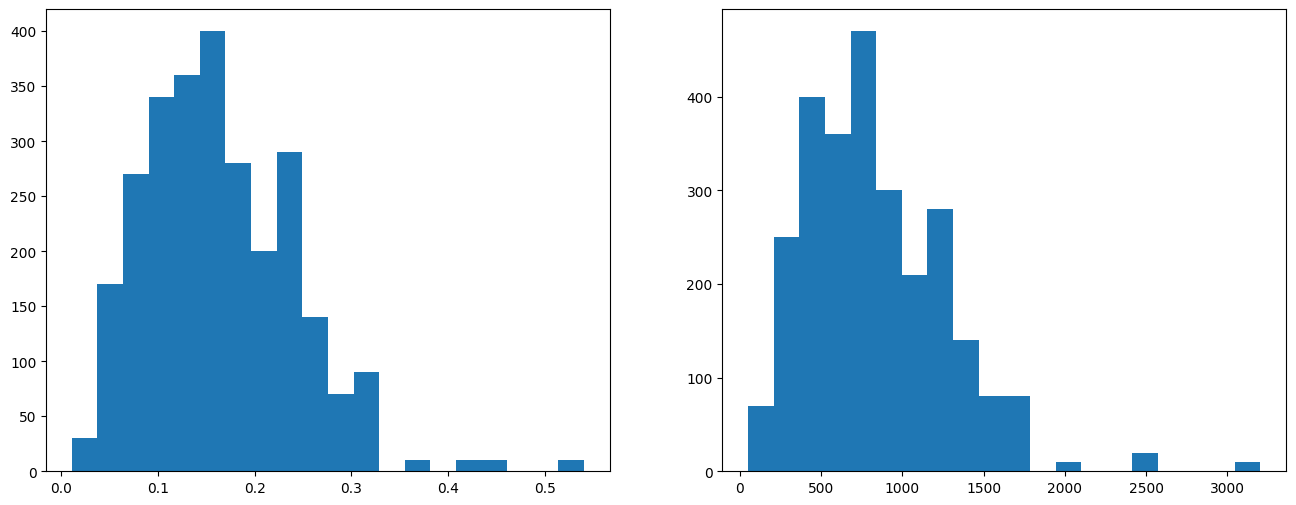

In [11]:
# distance column is luminosity distance in Mpc; convert to redshift via Planck18 cosmology
dist_aug = inj_aug['distance'].values * u.Mpc
# z_from_dist = np.vectorize(lambda d: z_at_value(Planck18.luminosity_distance, d, zmax=10))
redshift_aug = np.array([z_at_value(Planck18.luminosity_distance, d, zmax=10) for d in dist_aug])
plt.figure(figsize=(16,6))
plt.subplot(121)
plt.hist(redshift_aug,bins=20)
plt.subplot(122)
plt.hist(dist_aug, bins=20)

In [21]:
def r_peak(distmu, distsigma):
    """
    Calculate the peak distance from distmu and distsigma.(ansatz distribution)
    Note: (distnorm does not affect the peak position)
    """
    distmu = np.asarray(distmu, dtype=float)
    distsigma = np.asarray(distsigma, dtype=float)
    dist_peak = 0.5 * (distmu + np.sqrt(distmu**2 + 8.0 * distsigma**2))
    return dist_peak

def get_peak_dist(mocmap, level=0.9, within=True):
    """
    Sample sky coordinates from a MOC skymap within/without a credible level.
    """

    uniq = mocmap['UNIQ']
    probdensity = mocmap['PROBDENSITY']
    distmu = mocmap['DISTMU']
    distsigma = mocmap['DISTSIGMA']

    # 2) caculate pixel area
    dA = uniq2pixarea(uniq)
    # 3) calculate pixel probability
    dP = probdensity * dA
    # 4) calculate credible levels
    cls = postprocess.find_greedy_credible_levels(
        dP, probdensity
    )
    cls = np.where(cls>1, 1.0, cls)

    if within:
        mask = cls <= level
    else:
        mask = cls >= level
    
    # calculate distance with peak pdf from distmu and distsigma
    distmu = np.array(distmu[mask], dtype=float)
    distsigma = np.array(distsigma[mask], dtype=float)

    # remove nan values
    valid = np.isfinite(distmu) & np.isfinite(distsigma) & (distsigma>0)
    distmu = distmu[valid]
    distsigma = distsigma[valid]
    dist_peak = r_peak(distmu, distsigma)

    return dist_peak